
<a href="https://colab.research.google.com/github/kokchun/Machine-learning-AI22/blob/main/Exercises/E04_logistic_regression.ipynb" target="_parent"><img align="left" src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> &nbsp; to see hints and answers.

---
# Logistic regression exercises 

---
These are introductory exercises in Machine learning with focus in **logistic regression**

<p class = "alert alert-info" role="alert"><b>Note</b> that sometimes you don't get exactly the same answer as I get, but it doesn't neccessarily mean it is wrong. Could be some parameters, randomization, that we have different. Also very important is that in the future there won't be any answer sheets, use your skills in data analysis, mathematics and statistics to back up your work.</p>

<p class = "alert alert-info" role="alert"><b>Note</b> that in cases when you start to repeat code, try not to. Create functions to reuse code instead. </p>

<p class = "alert alert-info" role="alert"><b>Remember</b> to use <b>descriptive variable, function, index </b> and <b> column names</b> in order to get readable code </p>

The number of stars (\*), (\*\*), (\*\*\*) denotes the difficulty level of the task

---

## 0. Iris flower dataset (*)

In the whole exercise, we will work with the famous Iris flower dataset, which was collected in 1936 by Ronald Fisher, a statistician and biologist. Use the ```datasets``` module from scikit-learn to load the iris dataset. 

&nbsp; a) Check keys on the loaded data and check what the different values for each key are.

&nbsp; b) Now insert the data into a DataFrame. 

&nbsp; c) Do some EDA to get an understanding of the dataset. 

&nbsp; d) Make a correlation heatmap to see how each feature is correlated to each other. What do the numbers mean?

&nbsp; e) Make a boxplot. The points outside of the boxplot are statistically calculated outliers using Tukey's rule for boxplot. 

&nbsp; f) Now remove the outliers in data. (**)

- Lower bound outlier: $Q_1 - 1.5\cdot IQR$
- Upper bound outlier: $Q_3 + 1.5\cdot IQR$

where $Q_1$ is the 1st quartile or 25 percentile, $Q_3$ is the 3rd quartile or 75 percentile and $IQR = Q_3-Q_1$ is the interquartile range. 

<details>

<summary>Hint</summary>

a) For DESCR key you need to print it.

f) Dataframes has a quantile method.  

</details>

<details>

<summary>Answer</summary>

b) 

|    |   sepal length (cm) |   sepal width (cm) |   petal length (cm) |   petal width (cm) |   species | specie_name   |
|---:|--------------------:|-------------------:|--------------------:|-------------------:|----------:|:--------------|
|  0 |                 5.1 |                3.5 |                 1.4 |                0.2 |         0 | setosa        |
|  1 |                 4.9 |                3   |                 1.4 |                0.2 |         0 | setosa        |
|  2 |                 4.7 |                3.2 |                 1.3 |                0.2 |         0 | setosa        |
|  3 |                 4.6 |                3.1 |                 1.5 |                0.2 |         0 | setosa        |
|  4 |                 5   |                3.6 |                 1.4 |                0.2 |         0 | setosa        |

c) When you do describe, remove species as its statistical values are meaningless. 

|                   |    mean |      std |   min |   25% |   50% |   75% |   max |
|:------------------|--------:|---------:|------:|------:|------:|------:|------:|
| sepal length (cm) | 5.84333 | 0.828066 |   4.3 |   5.1 |  5.8  |   6.4 |   7.9 |
| sepal width (cm)  | 3.05733 | 0.435866 |   2   |   2.8 |  3    |   3.3 |   4.4 |
| petal length (cm) | 3.758   | 1.7653   |   1   |   1.6 |  4.35 |   5.1 |   6.9 |
| petal width (cm)  | 1.19933 | 0.762238 |   0.1 |   0.3 |  1.3  |   1.8 |   2.5 |


<img src = "../Data/pairplot_iris.png" height=300>

Do more EDA than I show here. 

d) Correlation heatmap

<img src = "../Data/Correlation_iris.png" height=300>

The closer the value is to 1 between two features, the more positively linear relationships between them. The closer the value is to -1 the more negatively linear relationships between them. 

e) 

<img src = "../Data/boxplot_iris.png" height=200>

f)
Outlier rows are: [13, 15, 22, 23, 24, 41, 43, 44, 98, 106, 117, 119, 131]

value counts:

|            |   specie_name |
|:-----------|--------------:|
| versicolor |            49 |
| virginica  |            46 |
| setosa     |            42 |

</details>

---

In [324]:
from sklearn.datasets import load_iris
import pandas as pd

# A
data = load_iris(as_frame=True)

for key in data.keys():
    print(key.upper())
    print(f"{data[key] }\n")

# B
df = data.frame.copy()
df['species name'] = df['target'].apply(lambda i: data.target_names[i])
df.head()

DATA
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                  5.1               3.5                1.4               0.2
1                  4.9               3.0                1.4               0.2
2                  4.7               3.2                1.3               0.2
3                  4.6               3.1                1.5               0.2
4                  5.0               3.6                1.4               0.2
..                 ...               ...                ...               ...
145                6.7               3.0                5.2               2.3
146                6.3               2.5                5.0               1.9
147                6.5               3.0                5.2               2.0
148                6.2               3.4                5.4               2.3
149                5.9               3.0                5.1               1.8

[150 rows x 4 columns]

TARGET
0      0
1      0
2      0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species name
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species name       150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


None

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


target
0    50
1    50
2    50
Name: count, dtype: int64

<Axes: >

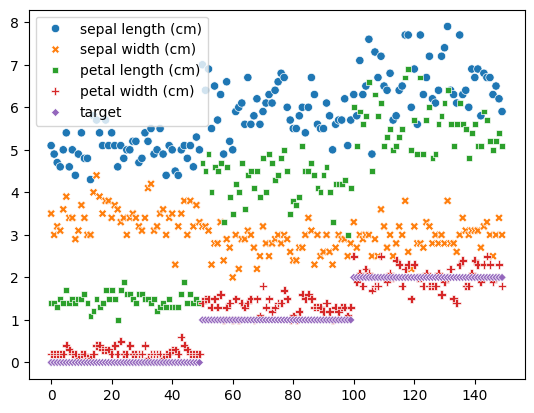

In [325]:
# C
display(df.info())
display(df.drop('target', axis=1).describe())
display(df["target"].value_counts())

import seaborn as sns
sns.scatterplot(df)

<Axes: >

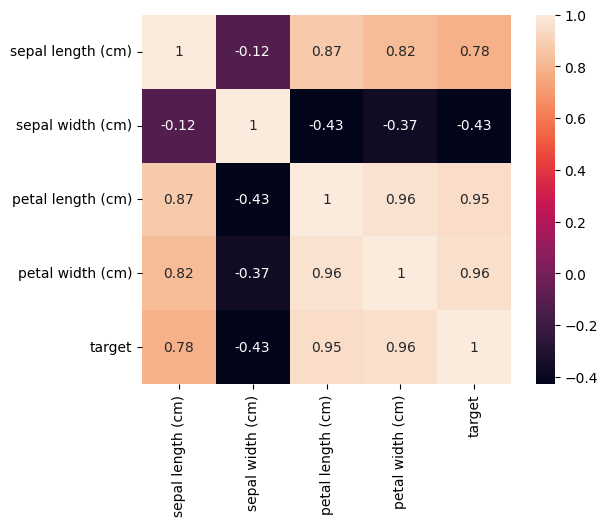

In [326]:
# D
df_numeric = df.drop('species name', axis=1)
sns.heatmap(df_numeric.corr(), annot=True, square=True)

# -> OWN RELECTIONS:
# Petal length and width are strongly correlated with target, which we also can see at the scatter matrix above. This is good.
# Sepal length also have a good correlation with the target, while sepal width has a somewhat weaker correlation to it.
# Petal width and petal length are almost linearly correlated, which is not that surprising since it's just two measures of the same petal.
# Sepal width and sepal length, on the other hand, have close to no correlation which is more surprising. Their relationship almost seem 'random'.

# -> AFTER FEEDING COPILOT MY ANALYSIS IT ADDED:
# The correlation between petal width and length could cause multicollinearity between them, which might get problematic if a linear model is chosen.
# Models that build around the petal features (like logistic regression or decision trees) often reach 100% accuracy on this dataset.
# The almost non-exisiting correlation between sepal width and lenth might be a result of greater variances within, rather than between, species.

<Axes: >

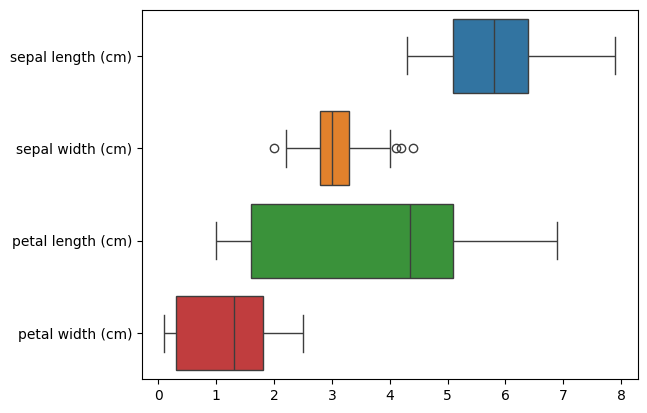

In [327]:
# E
sns.boxplot(df.drop("target", axis=1), orient="y")

&nbsp; f) Now remove the outliers in data. (**)

- Lower bound outlier: $Q_1 - 1.5\cdot IQR$
- Upper bound outlier: $Q_3 + 1.5\cdot IQR$

2.05 4.05
(150, 6)
(146, 6)


<Axes: >

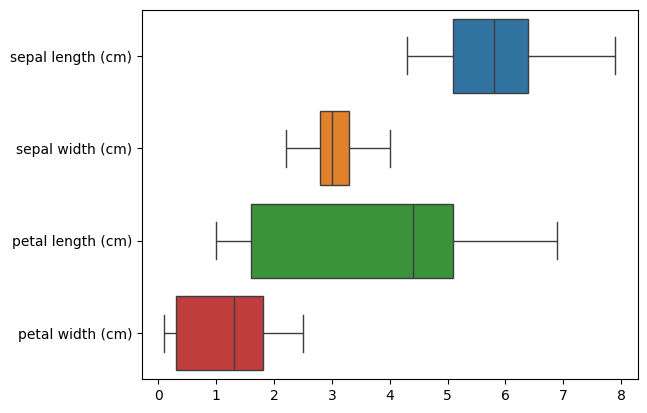

In [328]:
# F

IQR = df["sepal width (cm)"].quantile(0.75) - df["sepal width (cm)"].quantile(0.25)
lower = df["sepal width (cm)"].quantile(0.25) - 1.5 * IQR
upper = df["sepal width (cm)"].quantile(0.75) + 1.5 * IQR
print(lower, upper)

print(df.shape)
df = df[(df["sepal width (cm)"] > lower) & (df["sepal width (cm)"] < upper)]
print(df.shape)

sns.boxplot(df.drop("target", axis=1), orient="y")

## 1. Split and scale data (*)

Do train|test split and scale the data using feature standardization, I used default test size 0.33 and random state 42. Check the mean and standard deviation on training and test data. 

---

In [329]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop(["target", "species name"], axis=1).copy()
y = df[["target", "species name"]].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
print(f"X_train mean:\n{X_train.mean()}\n")
print(f"X_train std:\n{X_train.std()}\n")
print(f"X_test mean:\n{X_test.mean()}\n")
print(f"X_test std:\n{X_test.std()}\n")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train mean:
sepal length (cm)    5.875258
sepal width (cm)     3.023711
petal length (cm)    3.875258
petal width (cm)     1.230928
dtype: float64

X_train std:
sepal length (cm)    0.871066
sepal width (cm)     0.414772
petal length (cm)    1.719740
petal width (cm)     0.723758
dtype: float64

X_test mean:
sepal length (cm)    5.820408
sepal width (cm)     3.073469
petal length (cm)    3.671429
petal width (cm)     1.200000
dtype: float64

X_test std:
sepal length (cm)    0.762938
sepal width (cm)     0.363877
petal length (cm)    1.842100
petal width (cm)     0.832917
dtype: float64



## 2. Classify with logistic regression (*)

Use k-folded cross-validation with logistic regression to find suitable hyperparameters and model. Check the documentation to see which parameters that can be chosen through cross-validation. Check the models parameters and see what it has chosen. 

<details>

<summary>Answer</summary>

weights: 

```py
array([[-1.33033256,  1.35076961, -2.26169407, -2.07715072],
       [ 0.40073538, -0.28598722, -0.58388865, -0.7782766 ],
       [ 0.67977172, -0.81485664,  3.09503329,  3.10542664]])
```

$\ell_1$-ratio:

```py
array([0.2, 0.2, 0.2])
```


<img src = "../assets/pairplot_iris.png" height=300>

Do more EDA than I show here. 

d) Correlation heatmap

<img src = "../assets/Correlation_iris.png" height=300>

The closer the value is to 1 between two features, the more positively linear relationships between them. The closer the value is to -1 the more negatively linear relationships between them. 

e) 

<img src = "../assets/boxplot_iris.png" height=200>

f)
Outlier rows are: [13, 15, 22, 23, 24, 41, 43, 44, 98, 106, 117, 119, 131]

value counts:

|            |   specie_name |
|:-----------|--------------:|
| versicolor |            49 |
| virginica  |            46 |
| setosa     |            42 |

</details>

---

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train['target'])
y_pred = model.predict(X_test_scaled)

scores = cross_val_score(model, X, y['target'], cv=10)
print(round(scores.mean(), 2))

0.97


## 3. Evaluate model (*)

Make a prediction on the testing data. 

&nbsp; a) Check manually the first 10 values of $y_{test}$ against your prediction. 

&nbsp; b) Plot a confusion matrix. Can you see which predictions the model have mispredicted?

&nbsp; c) Print a classification report 

<details>

<summary>Answer</summary>


b) 

<img src = "../Data/confusion_matrix_iris.png" height=300>



c) 

Classification report 

```py
          precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      0.94      0.97        16
           2       0.94      1.00      0.97        16

    accuracy                           0.98        46
   macro avg       0.98      0.98      0.98        46
weighted avg       0.98      0.98      0.98        46
```






</details>

---

     target  y_pred
48        0       0
101       2       2
28        0       0
20        0       0
45        0       0
124       2       2
30        0       0
84        1       1
70        1       2
19        0       0


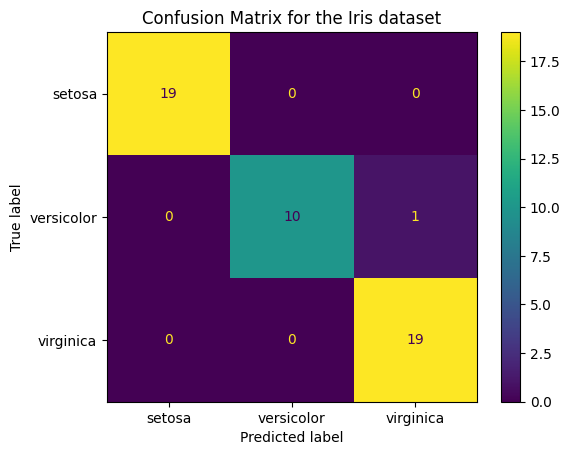

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.91      0.95        11
           2       0.95      1.00      0.97        19

    accuracy                           0.98        49
   macro avg       0.98      0.97      0.98        49
weighted avg       0.98      0.98      0.98        49



In [331]:
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# A
y_pred_df = pd.DataFrame(y_pred, index=y_test.index, columns=["y_pred"])
y_sidebyside = pd.concat([y_test["target"], y_pred_df], axis=1)
print(y_sidebyside[:10])

# B
matrix = confusion_matrix(y_test['target'], y_pred)
plot = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=data.target_names)
plot.plot()
plt.title("Confusion Matrix for the Iris dataset")
plt.show()

# C
print(classification_report(y_test['target'], y_pred))

In [332]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def result_per_label(label):
    y_true_binary = (y_test['target'] == label).astype(int)
    y_pred_binary = (y_pred == label).astype(int)

    precision, recall, fscore, _ = precision_recall_fscore_support(y_true_binary, y_pred_binary, average="binary")

    table = pd.DataFrame({
        "precision": round(precision, 2), 
        "recall": round(recall, 2), 
        "f-score": round(fscore, 2)
        }, index=[data.target_names[label]])
    
    return table

df_all_targets = pd.concat([
    result_per_label(label=0), 
    result_per_label(label=1), 
    result_per_label(label=2)])
display(df_all_targets)

accuracy = accuracy_score(y_test['target'], y_pred)
round(accuracy, 2)

,precision,recall,f-score
setosa,1.00,1.00,1.00
versicolor,1.00,0.91,0.95
virginica,0.95,1.00,0.97


0.98

## 4. $k$-folded cross-validation for evaluation (**)

To be more robust in reporting the results, you should report the results as $\mu_{score}$, i.e. average score through a k-folded cross-validation. Report the score for precision, recall, f1-score for each label and overall accuracy. Do the cross-validation manually using for statement. 

---

Kokchun Giang

[LinkedIn][linkedIn_kokchun]

[GitHub portfolio][github_portfolio]

[linkedIn_kokchun]: https://www.linkedin.com/in/kokchungiang/
[github_portfolio]: https://github.com/kokchun/Portfolio-Kokchun-Giang

---